In [208]:
from google_play_scraper import reviews_all, Sort
import pandas as pd

print("Mulai scraping...")

ipusnas_reviews = reviews_all(
    'mam.reader.ipusnas',
    sleep_milliseconds=0,
    lang='id',
    country='id',
    sort=Sort.NEWEST
)

print("Scraping selesai!")

# Convert ke DataFrame
df = pd.DataFrame(ipusnas_reviews)

print("Jumlah review yang berhasil diambil:", len(df))

# Simpan ke CSV
df.to_csv("ipusnas_reviews_all.csv", index=False)

df.head()

Mulai scraping...
Scraping selesai!
Jumlah review yang berhasil diambil: 20262


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b9151a45-04c1-454c-858f-9156565ad875,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ini ada yg ngurusin engga aplikasinya? dari du...,2,0,2.1.2,2026-03-24 01:01:52,None,NaT,2.1.2
1,82c80ff1-d650-46d4-9c4e-b5d98feaade4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,halaman awal: javalang bla bla bla cenah. wakt...,1,0,2.1.2,2026-03-23 23:07:50,None,NaT,2.1.2
2,53625f25-a762-4659-ba46-5109cb1af727,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi tolol gak berguna. Kena imbas efisien...,1,0,2.1.2,2026-03-23 21:50:39,None,NaT,2.1.2
3,90e3ab08-d690-4343-94e1-f79d265f6e46,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Banyakan eror, mau login eror, mau pinjam eror",1,0,2.1.2,2026-03-23 21:49:46,None,NaT,2.1.2
4,a2226ba3-3a6c-405e-9a5b-86eaa3be2e21,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kacau bangt ni apk, kaya cuma di kasih harapan...",1,0,None,2026-03-23 20:28:14,None,NaT,None


In [209]:
df.shape

(20262, 11)

In [211]:
df.describe()

,score,thumbsUpCount,at,repliedAt
count,20262.000000,20262.000000,20262,13128
mean,2.837035,1.887523,2022-05-16 19:36:33.447685120,2020-10-06 20:04:44.260816640
min,1.000000,0.000000,2016-08-16 14:28:20,2016-12-02 08:32:38
25%,1.000000,0.000000,2019-11-26 12:19:06.750000128,2019-05-24 08:14:07.750000128
50%,3.000000,0.000000,2021-11-23 16:29:19,2020-07-26 13:34:40
75%,5.000000,0.000000,2025-01-19 11:34:47.750000128,2021-11-25 11:24:46.249999872
max,5.000000,2284.000000,2026-03-24 01:01:52,2025-09-09 14:50:16
std,1.658701,24.734835,NaN,NaN


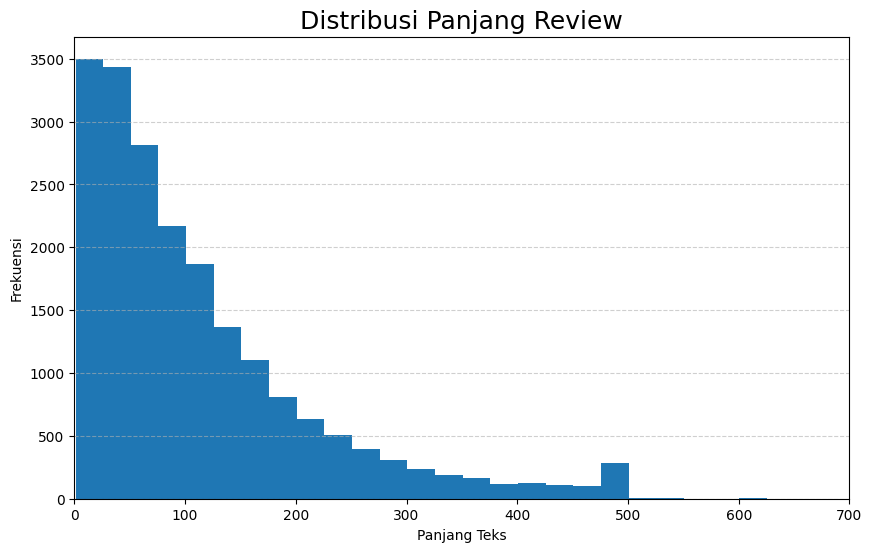

In [212]:
import matplotlib.pyplot as plt

text_column = 'content' 

df['text_length'] = df['content'].astype(str).apply(len)

plt.figure(figsize=(10,6))
plt.hist(df['text_length'], bins=50)

plt.title("Distribusi Panjang Review", fontsize=18)
plt.xlabel("Panjang Teks")
plt.ylabel("Frekuensi")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.xlim(0, 700)

plt.show()

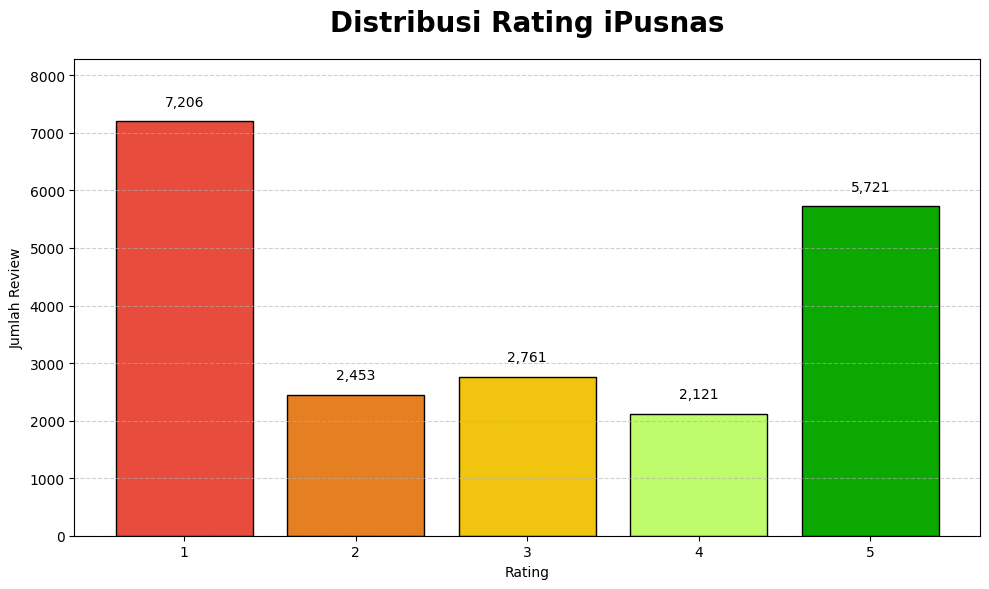

In [213]:
df_count = df['score'].value_counts().sort_index()

score_colors = {
    1: '#e74c3c',
    2: '#e67e22',
    3: '#f1c40f',
    4: '#bffc6b',
    5: '#0aa800',
}

colors = [score_colors[score] for score in df_count.index]

plt.figure(figsize=(10, 6))

bars = plt.bar(df_count.index, df_count.values, color=colors, edgecolor='black')

plt.title('Distribusi Rating iPusnas', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

max_val = max(df_count.values)
plt.ylim(top=max_val * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max_val * 0.03,
        f"{height:,}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [214]:
from collections import Counter

all_text = ' '.join(df['content'].dropna().astype(str)).lower()
words = all_text.split()

word_counts = Counter(words)
common_words = word_counts.most_common(20)

word_freq_df = pd.DataFrame(common_words, columns=['Word','Frequency'])
display(word_freq_df)

,Word,Frequency
0,bisa,8691
1,buku,6944
2,saya,5717
3,di,5394
4,aplikasi,4999
5,dan,4747
6,tidak,4553
7,yang,4262
8,ini,4124
9,ada,3222


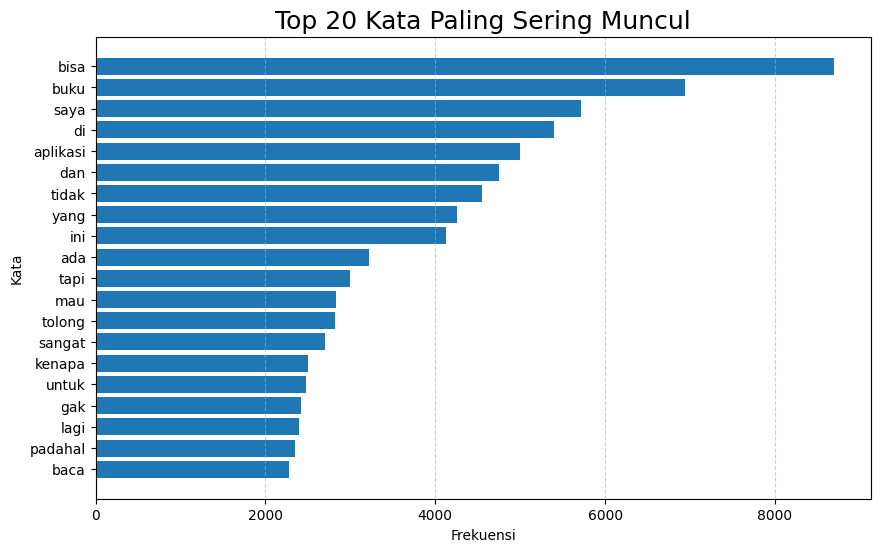

In [215]:
plt.figure(figsize=(10,6))

plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])

plt.title("Top 20 Kata Paling Sering Muncul", fontsize=18)
plt.xlabel("Frekuensi")
plt.ylabel("Kata")

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

In [217]:
print("Jumlah data:", len(df))
print("Rata-rata panjang review:", df['text_length'].mean())
print("Review terpanjang:", df['text_length'].max())
print("Review terpendek:", df['text_length'].min())

Jumlah data: 20262
Rata-rata panjang review: 111.58982331457902
Review terpanjang: 1250
Review terpendek: 1


In [218]:
# ---- WEEK 3 ------
import nltk
from nltk.corpus import stopwords
stop_words = set(stopwords.words('indonesian'))

In [219]:
# =========================
# STEMMER
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

# PROTECTED WORDS
protected_words = {
    'perpus','ipusnas','login','logout','email','password',
    'ebook','server','bug','error','aplikasi'
}

In [220]:
normalization_dict = {
    'gak': 'tidak','ga': 'tidak','g': 'tidak','nggak': 'tidak','engga': 'tidak','tdk': 'tidak','gk': 'tidak',
    'blm': 'belum',
    'bgt': 'banget', 'bgt' : 'bangt',
    'krn': 'karena','krna': 'karena','karna': 'karena',
    'unduh':'download','didownload':'download','diunduh':'download',
    'udah': 'sudah','sdh': 'sudah',
    'dpt': 'dapat','dapet': 'dapat',
    'ksh': 'kasih',
    'km': 'kamu',
    'pdhl':'padahal','knp':'kenapa',
    'eror':'error','ngebug':'bug',
    'app':'aplikasi','apknya':'aplikasi','aplikasinya':'aplikasi',
    'masuk':'login','keluar':'logout',
    'minjam':'pinjam','pinjem':'pinjam','meminjam':'pinjam',
    'diupdate':'update','diperbarui':'update',
    'lemot':'lambat',
    'trs':'terus','trus':'terus',
    'pake':'pakai','nyari':'cari','pengen':'ingin',
    'perpus':'perpustakaan',
}

def normalize_words(tokens):
    return [normalization_dict[word] if word in normalization_dict else word for word in tokens]

In [221]:
# Custom stopwords 
manual_stopwords = {
    'yang','dan','di','ke','dari','ini','ni','itu','ada','nya',
    'buat','untuk','utk','saya','aku','lagi','lg','tapi','kalau','kalo',
    'cuma','saja','hanya','juga','pas','mau','saat','akan',
    'dengan','kok','sih','dong','ya','apa','kenapa','mengapa',
    'bagaimana','mana','karena','jadi','terus','lalu',
    'kak','min','admin','aplikasi','apk', 'kok'
    'nih','tuh','lah','deh', 'yg','aja','sih','loh',
    'secara','tersebut','sebuah','malah','justru', 'padahal', 'kenapa',
    'supaya','agar',
    'gitu','begini','begitu',
    'setiap','semua','banyak','beberapa',
    'tadi','sekarang','nanti','dulu',
    'kyk','kayak','kaya',
    'krn','krna','karna',
    'emang','memang',
    'masa','ampe','sampai','hingga',
    'dpt','dapat','dapet',
    'kasih','ksh','beri','berikan',
    'mohon','tolong',
    'km','kamu','si',
    'sang','para','kaum',
    'kita','kami','anda','dia','ia','mereka','beliau','kalian',
    'sendiri','sama','atau','dalam','kali','seperti','ketika',
    'lain','tetap','versi','pada','namun','pun',
    'satu','orang','bagi','kan','soalnya','nih',
    'jika','bahkan','apalagi','cara','halo','eh',
    'sehingga','menjadi','adanya','jumlah','tahun'
    # conversational / filler
    'padahal','semoga','terima','terimakasih','makasih',
    'maaf','harap','alhamdulillah','salam',
    
    # vague / non-informative
    'coba','ingin','mungkin','kadang','langsung',
    'awal','akhir','akhirnya','terakhir',
    'segera','kembali','biar','bikin',
    
    # general verbs (kurang meaningful sendiri)
    'membuat','membuka','menggunakan','digunakan',
    'menambah','ditambah','ditambahkan','tambahkan',
    'meningkatkan','ditingkatkan',
    
    # waktu (kalau tidak dianalisis)
    'hari','kemarin','minggu','bulan','sebelum','setelah',
    
    # noise / typo / singkatan tambahan
    'tp','tpi','udh','dah','trs','trus','jg','jd','bs',
    'klo','pdhl','knp','sy','d',
    
    # conversational Indo banget
    'bener','oke','ok','yah','yaa','ko','nih','tuh',
    
    # low info
    'hal','nama','kata','bilang'
}

keep_words = {
    'tidak','gak','ga','nggak','engga','tdk','belum','blm',
    'banget','bgt','sangat','amat','terlalu',
    'harus','perlu','wajib','butuh',
    'sering','jarang','pernah','selalu',
    'rasanya','terasa','kelihatannya','sepertinya'
}

In [223]:
# =========================
# 🆕 TAMBAHAN: STEM FUNCTION
def stem_words(tokens):
    stemmed = []
    for word in tokens:
        if word in protected_words:
            stemmed.append(word)
        else:
            stemmed.append(stemmer.stem(word))
    return stemmed
# =========================
def preprocess_text(text):
    if pd.isna(text):
        return []
    
    text = text.lower()
    tokens = text.split()
    
    tokens = normalize_words(tokens)
    tokens = [word for word in tokens if word not in stop_words and word not in manual_stopwords]
    tokens = stem_words(tokens)
    
    return tokens

In [233]:
# =========================
# 1. CLEANING
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['content'].astype(str).apply(clean_text)

df['clean_text']

0        ini ada yg ngurusin engga aplikasinya dari dul...
1        halaman awal javalang bla bla bla cenah waktu ...
2        aplikasi tolol gak berguna kena imbas efisiens...
3             banyakan eror mau login eror mau pinjam eror
4        kacau bangt ni apk kaya cuma di kasih harapan ...
                               ...                        
20257                                                keren
20258                                    semoga bermanfaat
20259                     sesuai dengan kebutuhan saat ini
20260                                            deskripsi
20261                                         di coba dulu
Name: clean_text, Length: 20262, dtype: object

In [234]:
# =========================
# 2. TOKENIZATION
# =========================
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

df['tokens'].head()

0    [ini, ada, yg, ngurusin, engga, aplikasinya, d...
1    [halaman, awal, javalang, bla, bla, bla, cenah...
2    [aplikasi, tolol, gak, berguna, kena, imbas, e...
3    [banyakan, eror, mau, login, eror, mau, pinjam...
4    [kacau, bangt, ni, apk, kaya, cuma, di, kasih,...
Name: tokens, dtype: object

In [235]:
# =========================
# 3. STEMMING
# =========================
df['stemmed'] = df['tokens'].apply(stem_words)
df['stemmed']

0        [ini, ada, yg, ngurusin, engga, aplikasi, dari...
1        [halaman, awal, javalang, bla, bla, bla, cenah...
2        [aplikasi, tolol, gak, guna, kena, imbas, efis...
3        [banyak, eror, mau, login, eror, mau, pinjam, ...
4        [kacau, bangt, ni, apk, kaya, cuma, di, kasih,...
                               ...                        
20257                                              [keren]
20258                                      [moga, manfaat]
20259                   [sesuai, dengan, butuh, saat, ini]
20260                                          [deskripsi]
20261                                     [di, coba, dulu]
Name: stemmed, Length: 20262, dtype: object

In [237]:
# =========================
#  4. NORMALIZATION
# =========================
df['normalized'] = df['stemmed'].apply(normalize_words)
df['normalized']

0        [ini, ada, yg, ngurusin, tidak, aplikasi, dari...
1        [halaman, awal, javalang, bla, bla, bla, cenah...
2        [aplikasi, tolol, tidak, guna, kena, imbas, ef...
3        [banyak, error, mau, login, error, mau, pinjam...
4        [kacau, bangt, ni, apk, kaya, cuma, di, kasih,...
                               ...                        
20257                                              [keren]
20258                                      [moga, manfaat]
20259                   [sesuai, dengan, butuh, saat, ini]
20260                                          [deskripsi]
20261                                     [di, coba, dulu]
Name: normalized, Length: 20262, dtype: object

In [239]:
# =========================
# 5. STOPWORDS REMOVAL
# =========================
df['filtered'] = df['normalized'].apply(
    lambda words: [word for word in words if (word not in manual_stopwords) or (word in keep_words)]
)

print("===RESULT AFTER STOPWORDS REMOVAL===")
df[['content','normalized','stemmed','filtered']].head()

===RESULT AFTER STOPWORDS REMOVAL===


,content,normalized,stemmed,filtered
0,ini ada yg ngurusin engga aplikasinya? dari du...,"[ini, ada, yg, ngurusin, tidak, aplikasi, dari...","[ini, ada, yg, ngurusin, engga, aplikasi, dari...","[ngurusin, tidak, error, melulu]"
1,halaman awal: javalang bla bla bla cenah. wakt...,"[halaman, awal, javalang, bla, bla, bla, cenah...","[halaman, awal, javalang, bla, bla, bla, cenah...","[halaman, javalang, bla, bla, bla, cenah, wakt..."
2,Aplikasi tolol gak berguna. Kena imbas efisien...,"[aplikasi, tolol, tidak, guna, kena, imbas, ef...","[aplikasi, tolol, gak, guna, kena, imbas, efis...","[tolol, tidak, guna, kena, imbas, efisiensi, a..."
3,"Banyakan eror, mau login eror, mau pinjam eror","[banyak, error, mau, login, error, mau, pinjam...","[banyak, eror, mau, login, eror, mau, pinjam, ...","[error, login, error, pinjam, error]"
4,"kacau bangt ni apk, kaya cuma di kasih harapan...","[kacau, bangt, ni, apk, kaya, cuma, di, kasih,...","[kacau, bangt, ni, apk, kaya, cuma, di, kasih,...","[kacau, bangt, sisa, error, doang]"


In [241]:
# =========================
# WORD FREQUENCY AFTER STOPWORDS REMOVAL
all_words = [word for row in df['filtered'] for word in row]

word_counts = Counter(all_words)
common_words = word_counts.most_common(30)

word_freq_df = pd.DataFrame(common_words, columns=['Word','Frequency'])
display(word_freq_df)

,Word,Frequency
0,tidak,11019
1,buku,10199
2,bisa,9464
3,baca,4972
4,baik,3999
5,sudah,3979
6,pinjam,3850
7,login,3847
8,bagus,3178
9,ipusnas,2746


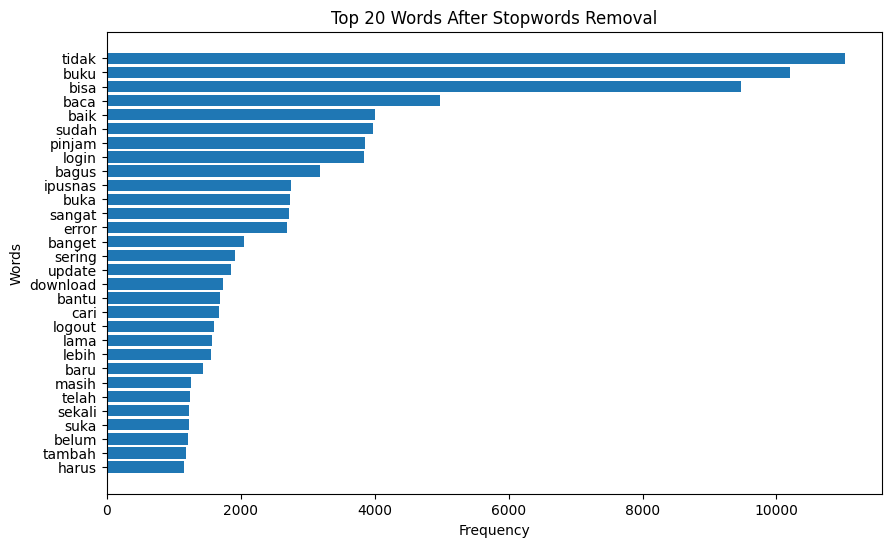

In [243]:
# =========================
# VISUALISASI
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])
plt.title("Top 20 Words After Stopwords Removal")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()